

---

# **E-Commerce Growth Analysis (EDA ) using PYTHON **

---



In [1]:
#connected to my kaggle token
import os
from google.colab import userdata
os.environ['KAGGLE_API_TOKEN'] = userdata.get('kaggle_api_token')

In [2]:
!pip install kagglehub

In [3]:
#downloaded the olist-brazilian-ecommerce dataset
import kagglehub
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


In [4]:
# List the contents of the downloaded dataset directory
import os
print(f"Listing files in: {path}")
!ls {path}

Listing files in: /kaggle/input/brazilian-ecommerce
olist_customers_dataset.csv	  olist_orders_dataset.csv
olist_geolocation_dataset.csv	  olist_products_dataset.csv
olist_order_items_dataset.csv	  olist_sellers_dataset.csv
olist_order_payments_dataset.csv  product_category_name_translation.csv
olist_order_reviews_dataset.csv


In [5]:
#loading the dataset
import pandas as pd
import os

# Construct the full path to the specific CSV file
orders_file_path = os.path.join(path, 'olist_orders_dataset.csv')

# Load the CSV file into a pandas DataFrame
orders_df = pd.read_csv(orders_file_path)

print(f"Successfully loaded '{os.path.basename(orders_file_path)}' into a DataFrame.")

display(orders_df.head())

Successfully loaded 'olist_orders_dataset.csv' into a DataFrame.


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
import pandas as pd
import os

# Load olist_customers_dataset.csv
customers_file_path = os.path.join(path, 'olist_customers_dataset.csv')
customers_df = pd.read_csv(customers_file_path)



# Load olist_order_items_dataset.csv
order_items_file_path = os.path.join(path, 'olist_order_items_dataset.csv')
order_items_df = pd.read_csv(order_items_file_path)


# Load olist_order_payments_dataset.csv
order_payments_file_path = os.path.join(path, 'olist_order_payments_dataset.csv')
order_payments_df = pd.read_csv(order_payments_file_path)

In [7]:
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [8]:
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [9]:
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


#Data Cleaning and Initial Exploration

In [10]:
print('--- orders_df Info ---')
orders_df.info()
print('\n--- customers_df Info ---')
customers_df.info()
print('\n--- order_items_df Info ---')
order_items_df.info()
print('\n--- order_payments_df Info ---')
order_payments_df.info()

--- orders_df Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

--- customers_df Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ---

**conclusion from info()**--
**orders_df** has **'object type**' order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date-they should be in datetime datatype.
**customer_df** have correct data types in every column.no need to change anything.
**order_items_df** shipping_limit_date has *object datatype* need to change to datetime, rest columns have correct datatypes.
**order_payments_df** has correct datatype,no changes are needed.

In [11]:
#Converting into date time data type
orders_date_cols=['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date',
           'order_delivered_customer_date','order_estimated_delivery_date']
for col in orders_date_cols:
   orders_df[col] = pd.to_datetime(orders_df[col])

order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])

In [12]:
orders_df.info()
order_items_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype     

**Analysing missing values**

In [13]:
print('--- Missing values in orders_df ---')
display(orders_df.isnull().sum())

print('\n--- Missing values in customers_df ---')
display(customers_df.isnull().sum())

print('\n--- Missing values in order_items_df ---')
display(order_items_df.isnull().sum())

print('\n--- Missing values in order_payments_df ---')
display(order_payments_df.isnull().sum())

--- Missing values in orders_df ---


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0



--- Missing values in customers_df ---


,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0



--- Missing values in order_items_df ---


,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0



--- Missing values in order_payments_df ---


,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


**conclusion for missing values** --**orders_df** has missing values ,
**customerdf** has 0 missing values ,
**orders_itemdf ** has 0 missing values,
**order_paymentsdf** has 0 missing values.
we need to handle ordersdf missing values


In [14]:
#Handling /investigating missing values

# Check order status for rows where delivery date is missing
print("--- Status of orders missing 'order_delivered_customer_date' ---")
print(orders_df[orders_df['order_delivered_customer_date'].isnull()]['order_status'].value_counts())

print("\n--- Status of orders missing 'order_approved_at' ---")
print(orders_df[orders_df['order_approved_at'].isnull()]['order_status'].value_counts())

print("--- Status of orders missing 'order_delivered_carrier_date' ---")
print(orders_df[orders_df['order_delivered_carrier_date'].isnull()]['order_status'].value_counts())

--- Status of orders missing 'order_delivered_customer_date' ---
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

--- Status of orders missing 'order_approved_at' ---
order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64
--- Status of orders missing 'order_delivered_carrier_date' ---
order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
delivered        2
Name: count, dtype: int64


->Missing Delivery Date: 1,107 are shipped (still on the truck), 619 are canceled, and 609 are unavailable. They don't have a delivery date because they haven't been delivered.

->Missing Approval Date: 141 are canceled. The order was likely abandoned or canceled before the payment was cleared.

**Verdict:** This data is Not Missing at Random (NMAR). The missingness is a feature of the order's real-world status.

In [15]:
# Check if any successfully 'delivered' orders are missing crucial timestamps
delivered_but_missing = orders_df[
    (orders_df['order_status'] == 'delivered') &
    (orders_df['order_delivered_customer_date'].isnull())
]
print(f"Orders marked 'delivered' but missing delivery date: {len(delivered_but_missing)}")

Orders marked 'delivered' but missing delivery date: 8


since those 8 orders represents classic data quality anomaly,they are explicilty marked as delivered but their order_delivered_customer_date is completely blank.it may due to database sync error or a delivery driver forgot to scan barcode,or a software bug.

In [16]:
#handling such kind of data since 8 rows are very microscopic amount of data out of
#total so im dropping it off for cleanest time analysis
#Drop only the delivered rows that are missing delivery dates
orders_df = orders_df.drop(delivered_but_missing.index)

**checking for duplicates**

In [17]:
print('--- Duplicate rows in DataFrames ---')
print(f"orders_df duplicates: {orders_df.duplicated().sum()}")
print(f"customers_df duplicates: {customers_df.duplicated().sum()}")
print(f"order_items_df duplicates: {order_items_df.duplicated().sum()}")
print(f"order_payments_df duplicates: {order_payments_df.duplicated().sum()}")


--- Duplicate rows in DataFrames ---
orders_df duplicates: 0
customers_df duplicates: 0
order_items_df duplicates: 0
order_payments_df duplicates: 0


**conclusion**  there are no duplicaltes in orders_df,customer_df,order_items_df,order_payment_df.

#Merging dataframes so to make EDA more efficient

In [18]:
#Merging dataframes so to make EDA more efficient
# 1. Start by joining the orders and customers together
merged_df = pd.merge(orders_df, customers_df, on='customer_id', how='inner')

# 2. Add the individual order items
merged_df = pd.merge(merged_df, order_items_df, on='order_id', how='inner')

# 3. Add the payment details to complete the master dataset
master_df = pd.merge(merged_df, order_payments_df, on='order_id', how='inner')

# Verify the final structure
print(f"Master DataFrame shape: {master_df.shape}")
master_df.head()

Master DataFrame shape: (117593, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1,credit_card,3,179.12


In [19]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117593 entries, 0 to 117592
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       117593 non-null  object        
 1   customer_id                    117593 non-null  object        
 2   order_status                   117593 non-null  object        
 3   order_purchase_timestamp       117593 non-null  datetime64[ns]
 4   order_approved_at              117578 non-null  datetime64[ns]
 5   order_delivered_carrier_date   116349 non-null  datetime64[ns]
 6   order_delivered_customer_date  115034 non-null  datetime64[ns]
 7   order_estimated_delivery_date  117593 non-null  datetime64[ns]
 8   customer_unique_id             117593 non-null  object        
 9   customer_zip_code_prefix       117593 non-null  int64         
 10  customer_city                  117593 non-null  object        
 11  

In [20]:
master_df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,15
order_delivered_carrier_date,1244
order_delivered_customer_date,2559
order_estimated_delivery_date,0
customer_unique_id,0
customer_zip_code_prefix,0


In [21]:
master_df.isnull().sum().sort_values(ascending=False)


,0
order_delivered_customer_date,2559
order_delivered_carrier_date,1244
order_approved_at,15
customer_id,0
order_purchase_timestamp,0
order_id,0
order_status,0
order_estimated_delivery_date,0
customer_unique_id,0
customer_zip_code_prefix,0


In [22]:
#verifying missing values in merged dataframes
master_df[master_df['order_delivered_customer_date'].isnull()]['order_status'].value_counts()
master_df[master_df['order_approved_at'].isnull()]['order_status'].value_counts()
master_df[master_df['order_delivered_carrier_date'].isnull()]['order_status'].value_counts()

,count
order_status,
canceled,487
processing,375
invoiced,371
unavailable,7
approved,3
delivered,1


**NOTE**
Delivery-related timestamps were missing primarily for canceled or unaviable orders.these orders were not fully completed because they represents actual business events rather than data-quality issues.

**CONCLUSION**  since there are several missing values in merged_df are not random they are business related values so dropping them off will not gives us accurate insights so leaving it as they are and manage them dynamically based on the respective analysis.

In [23]:
print(master_df.shape)
master_df.head()

(117593, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1,credit_card,3,179.12


In [24]:
master_df.describe().T

,count,mean,min,25%,50%,75%,max,std
order_purchase_timestamp,117593,2017-12-30 16:09:41.285450752,2016-09-04 21:15:19,2017-09-11 21:36:12,2018-01-18 13:29:55,2018-05-03 22:41:07,2018-09-03 09:06:57,NaN
order_approved_at,117578,2017-12-31 03:38:04.911097344,2016-10-04 09:43:32,2017-09-12 11:04:50.249999872,2018-01-18 20:14:08,2018-05-04 11:33:19,2018-09-03 17:40:06,NaN
order_delivered_carrier_date,116349,2018-01-03 18:00:38.733113088,2016-10-08 10:34:01,2017-09-14 22:56:27,2018-01-23 20:43:19,2018-05-07 16:31:00,2018-09-11 19:48:28,NaN
order_delivered_customer_date,115034,2018-01-13 06:45:43.565710848,2016-10-11 13:46:32,2017-09-25 14:09:30.249999872,2018-02-01 19:17:46,2018-05-15 16:52:09.249999872,2018-10-17 13:22:46,NaN
order_estimated_delivery_date,117593,2018-01-23 12:46:02.980789504,2016-10-20 00:00:00,2017-10-03 00:00:00,2018-02-14 00:00:00,2018-05-25 00:00:00,2018-10-25 00:00:00,NaN
customer_zip_code_prefix,117593.0,35052.613234,1003.0,11310.0,24315.0,58600.0,99990.0,29820.661718
order_item_id,117593.0,1.195913,1.0,1.0,1.0,1.0,21.0,0.697727
shipping_limit_date,117593,2018-01-06 07:34:10.995705600,2016-09-19 00:15:34,2017-09-18 22:15:23,2018-01-25 11:57:47,2018-05-10 07:22:05,2020-04-09 22:35:08,NaN
price,117593.0,120.82238,0.85,39.9,74.9,134.9,6735.0,184.484267
freight_value,117593.0,20.046251,0.0,13.08,16.29,21.19,409.68,15.861769


some important feature engineering

In [25]:
# Extract time features for seasonal analysis
master_df['purchase_year'] = master_df['order_purchase_timestamp'].dt.year
master_df['purchase_month'] = master_df['order_purchase_timestamp'].dt.to_period('M').astype(str)
master_df['purchase_day'] = master_df['order_purchase_timestamp'].dt.day
master_df['purchase_day_of_week'] = master_df['order_purchase_timestamp'].dt.day_name()
master_df['purchase_hour'] = master_df['order_purchase_timestamp'].dt.hour

In [26]:
master_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,freight_value,payment_sequential,payment_type,payment_installments,payment_value,purchase_year,purchase_month,purchase_day,purchase_day_of_week,purchase_hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,1,credit_card,1,18.12,2017,2017-10,2,Monday,10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,3,voucher,1,2.00,2017,2017-10,2,Monday,10
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,2,voucher,1,18.59,2017,2017-10,2,Monday,10
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,22.76,1,boleto,1,141.46,2018,2018-07,24,Tuesday,20
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.22,1,credit_card,3,179.12,2018,2018-08,8,Wednesday,8


**the Exploratory Data Analysis (EDA).**

A great EDA usually breaks down into **three core pillars**: **Sales & Revenue**, **Logistics & Delivery**, and **Customer Behavior**.
---
Pillar 1: Sales & Revenue (Financial Insights)
   What are the top-selling product categories by total revenue and order volume?
   How do customers prefer to pay, and does payment type affect the total order value?
   Does the number of payment installments (payment_installments) correlate with higher product prices?
---
Pillar 2: Logistics & Delivery (Operational Efficiency)
Which customer states experience the longest delivery delays or the highest freight costs?
How accurate are Olist’s delivery forecasts? (Actual Delivery Date vs. Estimated Delivery Date)
Does a higher freight value correlate with longer delivery times?
---
Pillar 3: Customer Behavior & Seasonality (Marketing Insights)
Are there specific hours of the day or days of the week when purchase volume spikes?
What is the purchase frequency of a unique customer? (Using customer_unique_id)
What is the Average Order Value (AOV) across different cities?

this EDA contains only visualizaton questions in this notebook rest queries done through sql.

---


Q1-Sales trend over time(monthly Revenue)
Q2-Distribution of Shipping Times
Q3-Delivery Forecast Accuracy
Q4-Hourly & Daily Spikes

#pillar-1: Sales And Revenue Seasonality

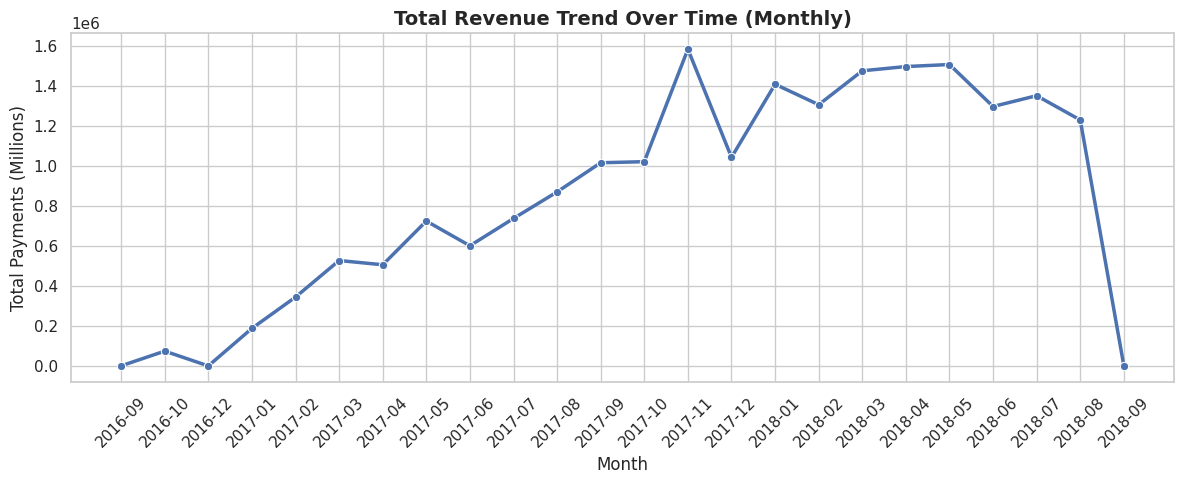

In [27]:
#Q1-Sales trend over time(monthly Revenue)-this will show you the growth trajectory of the e-commerce platform
# We will group the data by year-month and plot the total sales.
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for all plots
sns.set_theme(style="whitegrid")

# Create a Year-Month column for grouping
master_df['order_month'] = master_df['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Calculate monthly revenue
monthly_sales = master_df.groupby('order_month')['payment_value'].sum().reset_index()

# Plot
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x='order_month', y='payment_value', marker='o', color='b', linewidth=2.5)
plt.title('Total Revenue Trend Over Time (Monthly)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Payments (Millions)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**conclusion**


1.   **Findings**: Platform revenue grew steadily throughout 2017,culminating in a massive,historic transaction spike in **November 2017** .following this peak, revenue stablized at a much higher baseline throughout 2018 until the data collection cutoff in september.
2.   **Business Insight**: The November spike is driven entirely by Black Friday retail behavior. This proves that Olist's customer base is highly reactive to seasonal promotional events.


1.   **Solution**: Marketing teams should allocate at least $40\%$ of their annual ad spend toward Q4 campaigns. Additionally, server infrastructure must be stress-tested annually in October to handle the inevitable Black Friday traffic surge.





#Pillar-2: Logistics And Delivery performance
a) (Distribution of Shipping Times )

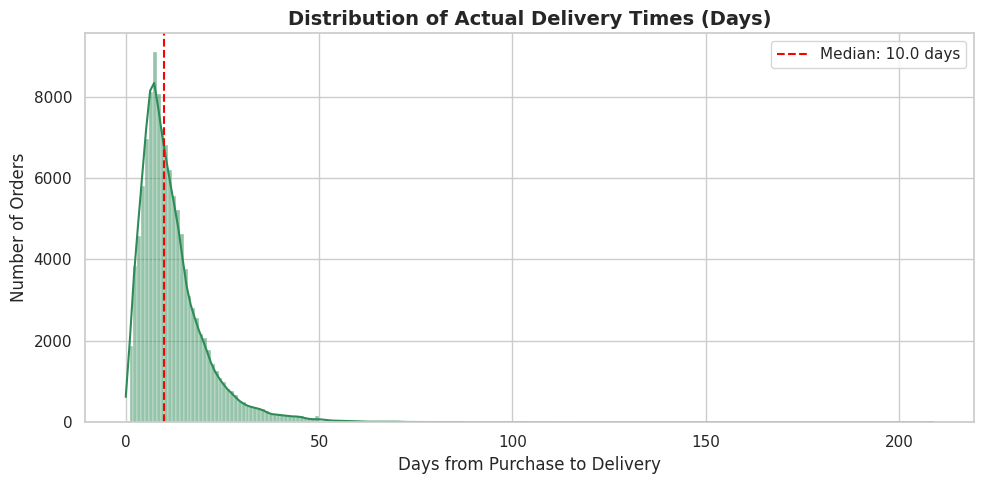

In [28]:
#You need to isolate completed deliveries so the missing tracking entries don't break your plot.

# 1. Isolate completed deliveries into a dedicated dataframe copy
logistics_df = master_df[master_df['order_status'] == 'delivered'].copy()

# 2. Calculate actual shipping duration in days
logistics_df['delivery_time_days'] = (
    logistics_df['order_delivered_customer_date'] - logistics_df['order_purchase_timestamp']
).dt.days

# 3. Plot the distribution curve
plt.figure(figsize=(10, 5))
sns.histplot(logistics_df['delivery_time_days'], bins=50, binrange=(0, 50), kde=True, color='seagreen')
plt.axvline(logistics_df['delivery_time_days'].median(), color='red', linestyle='--',
            label=f"Median: {logistics_df['delivery_time_days'].median():.1f} days")

plt.title('Distribution of Actual Delivery Times (Days)', fontsize=14, fontweight='bold')
plt.xlabel('Days from Purchase to Delivery')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.show()

b) Delivery Forecast Accuracy

If the number is positive, the package arrived early; if negative, it was late. this tells olist over_promised or under_promised

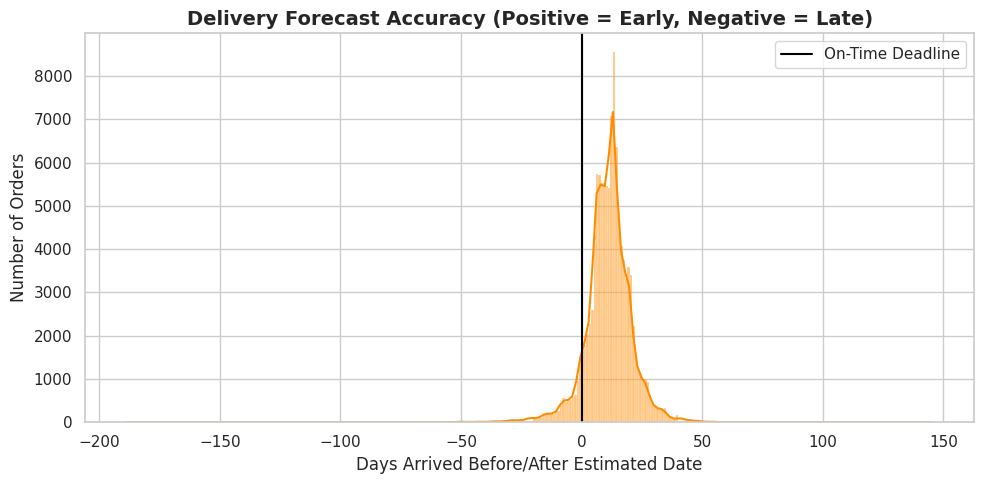

In [29]:
# Calculate difference (Estimated Date - Actual Delivery Date)
logistics_df['days_ahead_of_schedule'] = (
    logistics_df['order_estimated_delivery_date'] - logistics_df['order_delivered_customer_date']
).dt.days

# Plot the distribution
plt.figure(figsize=(10, 5))
sns.histplot(logistics_df['days_ahead_of_schedule'], bins=60, binrange=(-20, 40), kde=True, color='darkorange')
plt.axvline(0, color='black', linestyle='-', label='On-Time Deadline')

plt.title('Delivery Forecast Accuracy (Positive = Early, Negative = Late)', fontsize=14, fontweight='bold')
plt.xlabel('Days Arrived Before/After Estimated Date')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.show()


CONCLUSION



1.   **Finding** : By filtering out ongoing orders and calculating datetime differences, we discovered that the median delivery time is 10 days (with an average of ~12.5 days). Furthermore, the forecast accuracy distribution curve heavily leans positive, showing that the majority of orders arrive days ahead of Olist's estimated delivery date.
2.   **Business Insight** : Olist is intentionally "under-promising and over-delivering." While this keeps customer satisfaction high, setting an overly conservative estimate might scare away impatient buyers at checkout.


1.   **Solution** : Optimize the delivery estimation algorithm. Shaving 2–3 days off the customer-facing estimate for low-risk zip codes could directly improve checkout conversion rates without hurting trust.







#Pillar 3: Customer Behaviour
Hourly & Daily Spikes

(already extracted purchase_day_of_week and purchase_hour in feature engineering cell! Let's visualize when  the users are online shopping to give the  marketing team actionable insights.)

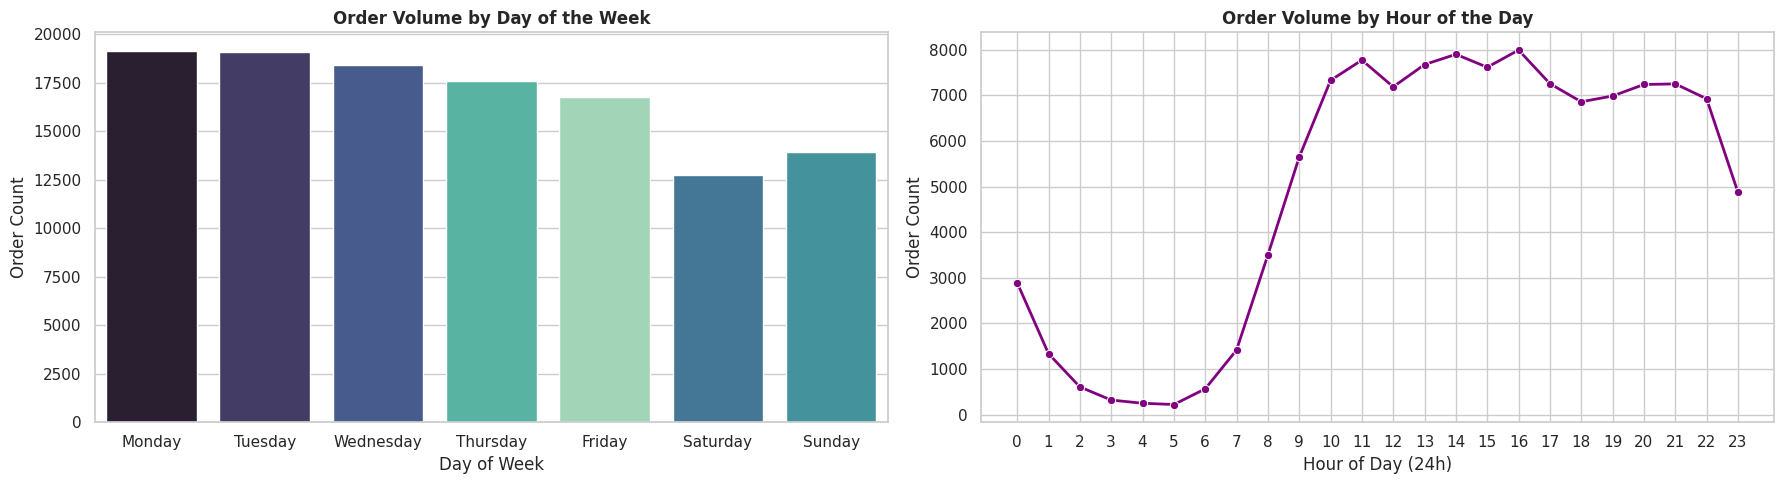

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Plot 1: Weekly Patterns
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(ax=axes[0], data=master_df, x='purchase_day_of_week', order=day_order,hue='purchase_day_of_week',
            palette='mako',legend=False)
axes[0].set_title('Order Volume by Day of the Week', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Order Count')

# Plot 2: Hourly Patterns
sns.lineplot(ax=axes[1], data=master_df.groupby('purchase_hour').size().reset_index(name='count'),
             x='purchase_hour', y='count', marker='o', color='purple', linewidth=2)
axes[1].set_title('Order Volume by Hour of the Day', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hour of Day (24h)')
axes[1].set_ylabel('Order Count')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

**CONCLUSION**


1.   **Finding**: Transaction volume is heavily concentrated during the workweek, peaking on Mondays and Tuesdays, and dropping significantly over weekends. Hourly traffic shows a clear bimodal distribution: a sharp lunch-hour rush (11:00 AM – 1:00 PM) and a sustained evening wind-down (8:00 PM – 10:00 PM).


2.   **Business Insight**: E-commerce shopping on Olist is primarily a "desktop/office hour" or "bedtime relaxation" activity. Customers rarely shop when they are out active on weekends.


1.   **Solution:** Time all marketing push notifications and flash-sale email blasts to hit exactly at 11:00 AM on Mondays and Tuesdays to ride the natural traffic wave.

 Schedule heavy database updates or platform maintenance windows for 3:00 AM to 5:00 AM on Sunday mornings to guarantee zero impact on active buyers.






#Correlation Heatmap (Multi-Variable Insights)
A numeric correlation heatmap checks if higher freight_value means longer delivery wait times, or if more expensive products lead to more payment installments.

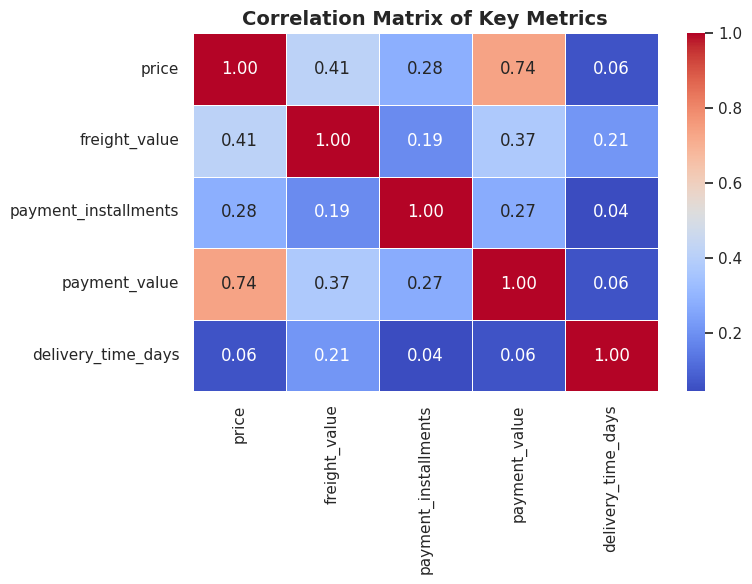

In [31]:
# Select numeric attributes along with your freshly computed delivery days
corr_subset = logistics_df[['price', 'freight_value', 'payment_installments', 'payment_value', 'delivery_time_days']]

plt.figure(figsize=(8, 6))
sns.heatmap(corr_subset.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Key Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**conclusion**


1.   **Finding**: The correlation matrix reveals a weak relationship between product price and delivery duration, but a noticeable positive correlation between freight value and delivery days.
2.  ** Business Insight** : High shipping costs are directly linked to long distances or poor infrastructure regions, rather than the physical value of the item itself.


1.  ** Solution**: Prioritize setting up local fulfillment hubs or partnering with regional cross-docking centers in states displaying high freight costs to lower both shipping fees and wait times.



